# Visualize backbone filter
- check if the current thresholds are reasonable

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_venn as venn
import numpy as np
import py3Dmol
import random

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [6]:
log_path = '/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/1000_filtered/filter_log.csv'
data = pd.read_csv(log_path)
data

,filename_old,filename_new,rg,n_residues,n_clashes,contacts_per_position,passes_rg,passes_nres,passes_clashes,passes_contacts,passes_all
0,/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/100/_0.pdb,NaN,20.571,95,0,{5: 0},True,True,True,False,False
1,/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/100/_1.pdb,/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/1000_filtered/kras_0.pdb,20.137,93,0,{5: 4},True,True,True,True,True
2,/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/100/_10.pdb,NaN,16.245,100,0,{5: 0},True,True,True,False,False
3,/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/100/_11.pdb,NaN,14.939,96,2,{5: 1},True,True,False,True,False
4,/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/100/_12.pdb,/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/1000_filtered/kras_1.pdb,16.936,76,0,{5: 2},True,True,True,True,True
5,/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/100/_13.pdb,/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/1000_filtered/kras_2.pdb,19.688,90,0,{5: 3},True,True,True,True,True
6,/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/100/_14.pdb,/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/1000_filtered/kras_3.pdb,17.032,77,0,{5: 4},True,True,True,True,True
7,/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/100/_15.pdb,NaN,11.795,85,0,{5: 3},False,True,True,True,False
8,/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/100/_16.pdb,NaN,11.303,91,1,{5: 0},False,True,False,False,False
9,/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/100/_17.pdb,/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/1000_filtered/kras_4.pdb,13.867,87,0,{5: 1},True,True,True,True,True


Total structures:  1000
Passed all filters: 525 (52.5%)

Filter                      Failed   % of total
-----------------------------------------------
Radius of Gyration             230        23.0%
N Residues                     162        16.2%
Clashes                        142        14.2%
Peptide Contacts               121        12.1%

Filters failed          Count   % of total
------------------------------------------
passed all                525        52.5%
failed 1                  325        32.5%
failed 2                  122        12.2%
failed 3                   26         2.6%
failed 4                    2         0.2%


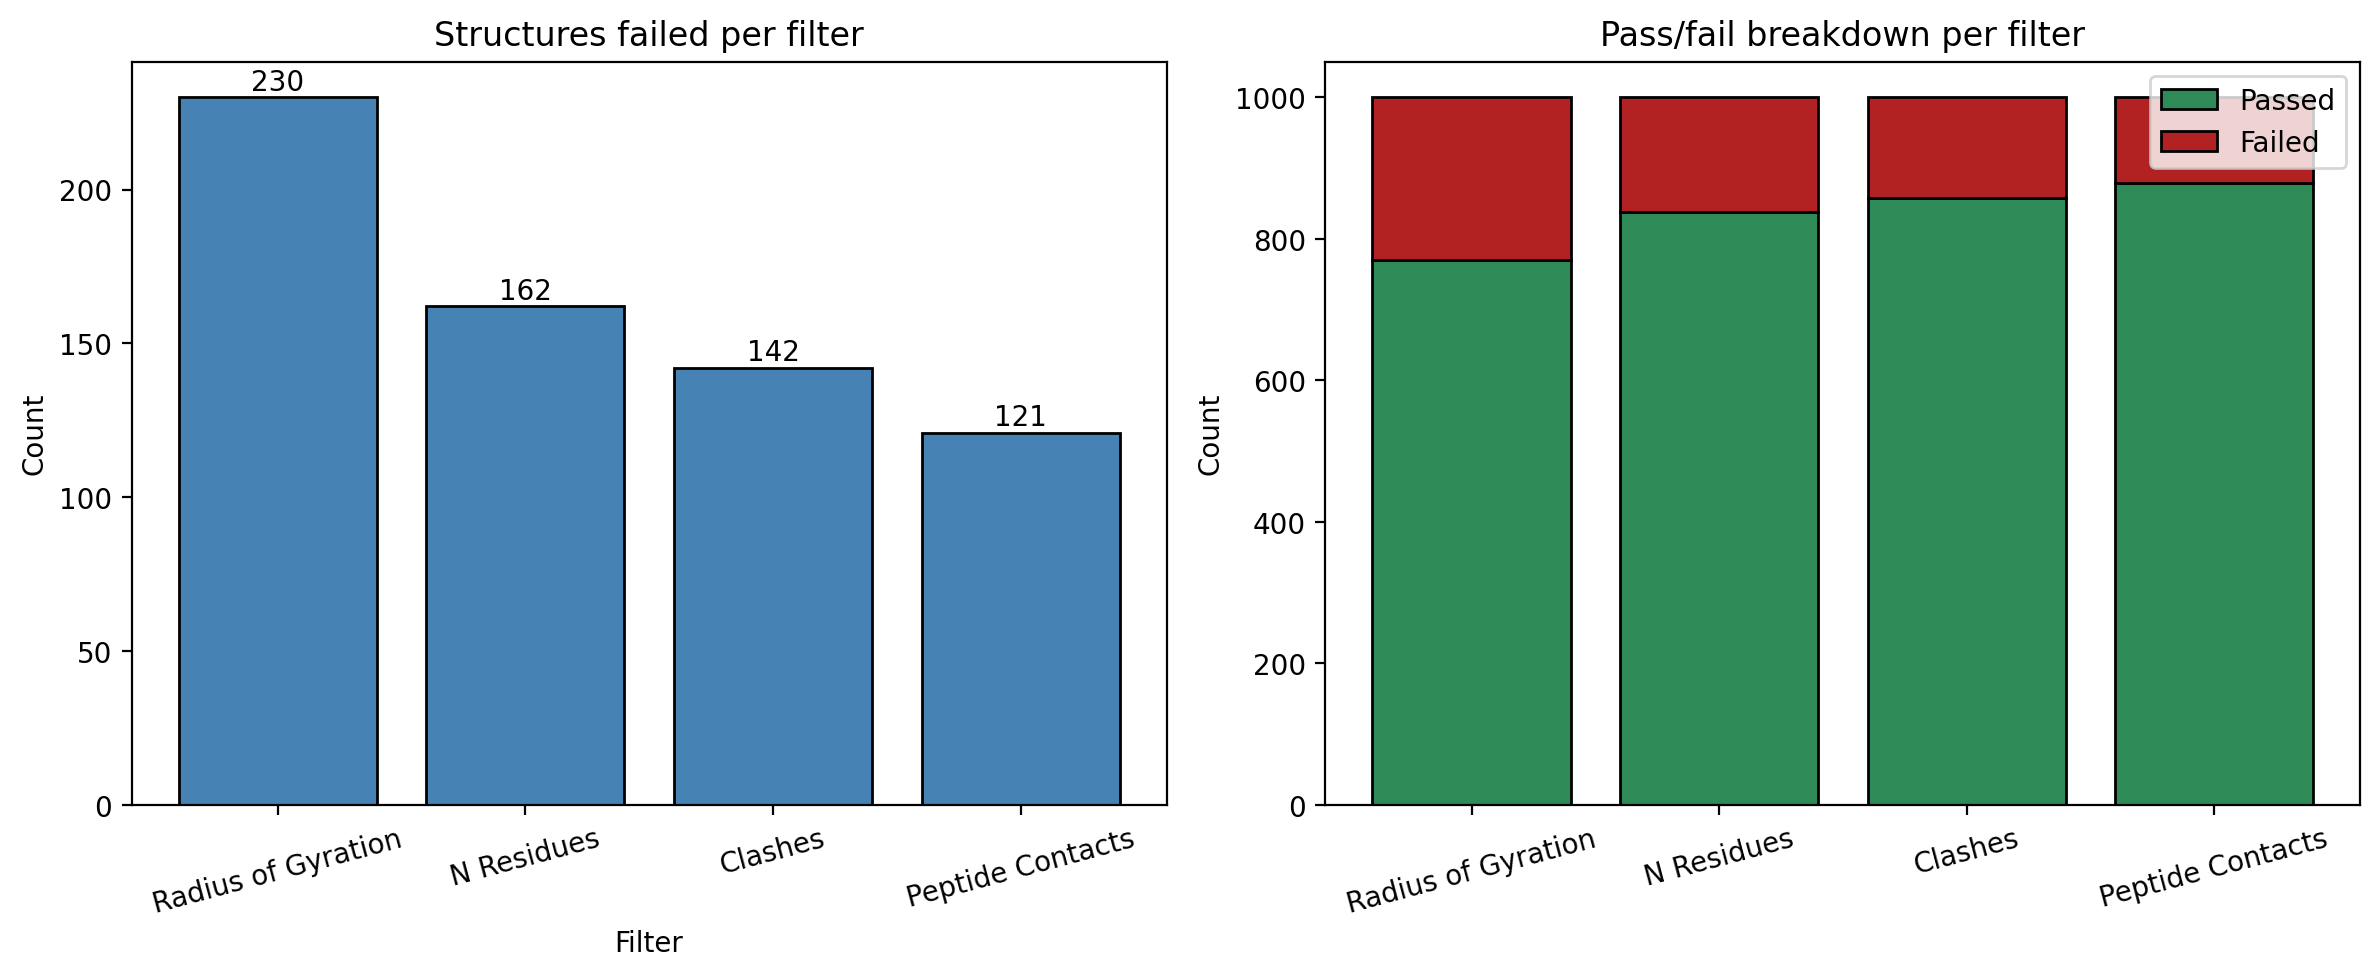

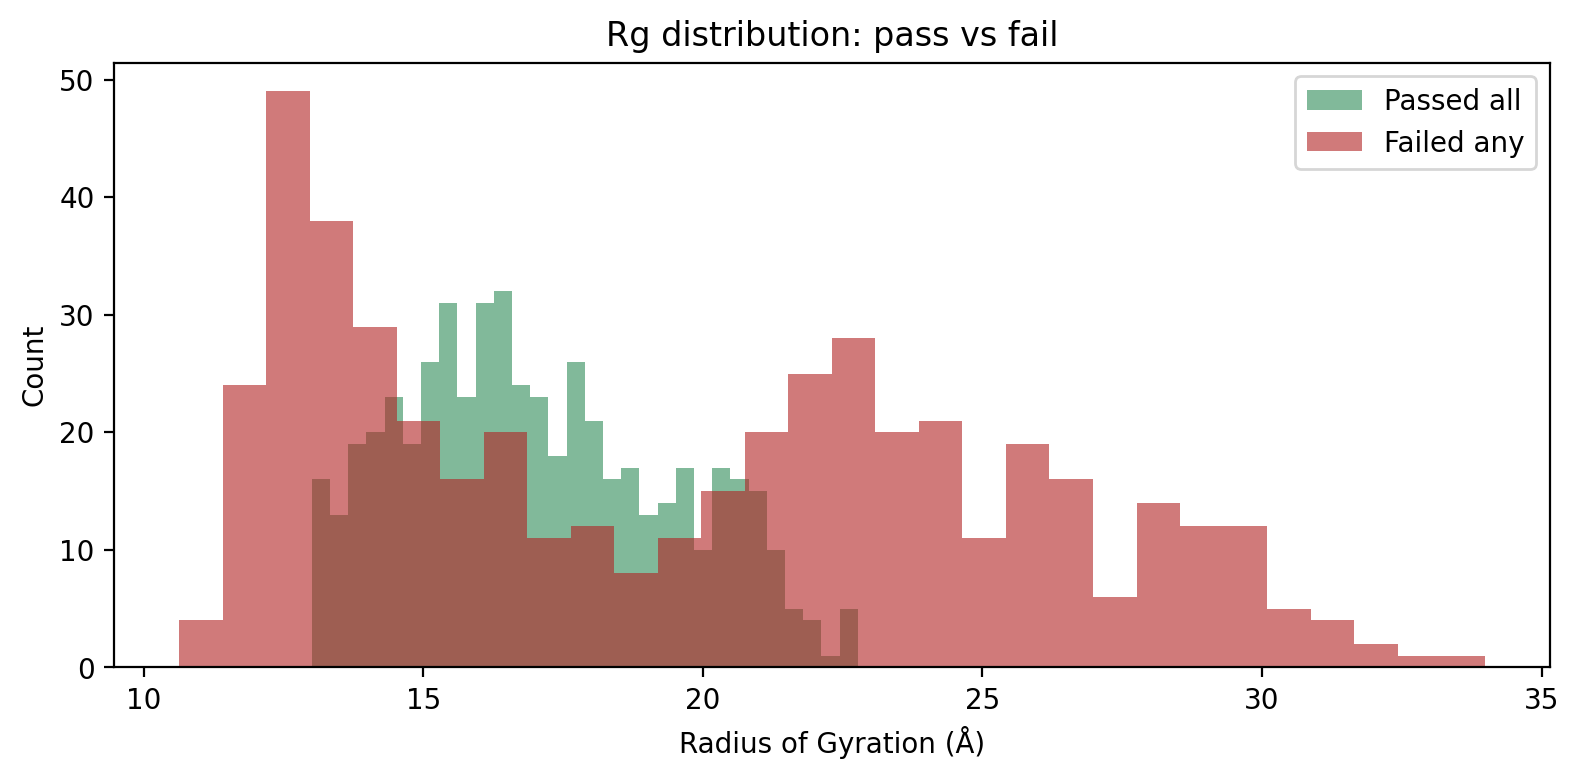

In [7]:
def analyze_filter_log(df, log_path):
    total = len(df)
    passed = df["passes_all"].sum()

    # ── Summary table ─────────────────────────────────────────────────────────
    filter_cols = {
        "passes_rg":       "Radius of Gyration",
        "passes_nres":     "N Residues",
        "passes_clashes":  "Clashes",
        "passes_contacts": "Peptide Contacts",
    }

    print(f"Total structures:  {total}")
    print(f"Passed all filters: {passed} ({100*passed/total:.1f}%)\n")
    print(f"{'Filter':<25} {'Failed':>8} {'% of total':>12}")
    print("-" * 47)
    for col, label in filter_cols.items():
        n_failed = (~df[col]).sum()
        print(f"{label:<25} {n_failed:>8} {100*n_failed/total:>11.1f}%")

    # ── How many failed exactly N filters ────────────────────────────────────
    df["n_failed"] = (~df[filter_cols.keys()]).sum(axis=1)  # wrong syntax fix below
    df["n_failed"] = df[[c for c in filter_cols]].apply(lambda row: (~row).sum(), axis=1)
    
    print(f"\n{'Filters failed':<20} {'Count':>8} {'% of total':>12}")
    print("-" * 42)
    for n, count in df["n_failed"].value_counts().sort_index().items():
        label = "passed all" if n == 0 else f"failed {n}"
        print(f"{label:<20} {count:>8} {100*count/total:>11.1f}%")

    # ── Plot 1: bar chart of failures per filter ──────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    failed_counts = {label: (~df[col]).sum() for col, label in filter_cols.items()}
    axes[0].bar(failed_counts.keys(), failed_counts.values(), color="steelblue", edgecolor="black")
    axes[0].set_title("Structures failed per filter")
    axes[0].set_ylabel("Count")
    axes[0].set_xlabel("Filter")
    axes[0].tick_params(axis="x", rotation=15)
    for i, (label, val) in enumerate(failed_counts.items()):
        axes[0].text(i, val + 0.5, str(val), ha="center", va="bottom", fontsize=10)

    # ── Plot 2: stacked bar showing pass/fail breakdown per filter ────────────
    passed_counts = {label: df[col].sum() for col, label in filter_cols.items()}
    labels  = list(filter_cols.values())
    failed  = [failed_counts[l] for l in labels]
    passing = [passed_counts[l] for l in labels]

    x = range(len(labels))
    axes[1].bar(x, passing, label="Passed", color="seagreen",   edgecolor="black")
    axes[1].bar(x, failed,  label="Failed", color="firebrick",  edgecolor="black",
                bottom=passing)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=15)
    axes[1].set_title("Pass/fail breakdown per filter")
    axes[1].set_ylabel("Count")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(log_path.replace(".csv", "_summary.png"), dpi=150)
    plt.show()

    # ── Plot 3: Rg distribution colored by pass/fail ──────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(df.loc[df["passes_all"],  "rg"], bins=30, alpha=0.6, color="seagreen",  label="Passed all")
    ax.hist(df.loc[~df["passes_all"], "rg"], bins=30, alpha=0.6, color="firebrick", label="Failed any")
    ax.set_xlabel("Radius of Gyration (Å)")
    ax.set_ylabel("Count")
    ax.set_title("Rg distribution: pass vs fail")
    ax.legend()
    plt.tight_layout()
    plt.savefig(log_path.replace(".csv", "_rg_dist.png"), dpi=150)
    plt.show()

    return df


df = analyze_filter_log(data, log_path)